# **Course Rating Prediction using Neural Networks**


In my previous work, I crafted several types of user and item feature vectors. For example, given a user `i`, I built profile feature vectors and course rating feature vectors, and for an item `j`, I created genre vectors and user enrollment vectors.



With these explicit feature vectors, I can perform machine learning tasks such as calculating similarities among users or items, finding nearest neighbors, and using dot-products to estimate rating values.

The main advantage of using these explicit features is they are highly interpretable and yield good performance. The main disadvantage is the considerable effort required to build and store them.


I demonstrated in previous notebooks that it is possible to predict ratings without building explicit feature vectors. Non-negative Matrix Factorization (NMF) decomposes the user-item interaction matrix into user and item matrices. These matrices contain latent features of users and items, and I can simply take their inner product to get an estimated rating.


In addition to NMF, neural networks can also extract latent user and item features. In fact, neural networks excel at learning patterns from data and are widely used to extract latent features. During training, neural networks gradually capture and store features within their hidden layers as weight matrices, which can be extracted to represent the original data.


In this notebook, I'll train neural networks to predict course ratings while simultaneously extracting users' and items' latent features.


## Objectives


In this notebook, I will:


* Use `tensorflow` to train neural networks that extract user and item latent features from hidden layers
* Predict course ratings with trained neural networks


----


## Environment Setup


In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
%cd "/content/drive/Othercomputers/My MacBook Pro/portfolio/rec_sys_edits"
file_prefix = %pwd

/content/drive/Othercomputers/My MacBook Pro/portfolio/rec_sys_edits


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

In [5]:
# Set a random state for reproducibility
rs = 123

### Loading and Processing the Rating Dataset


In [6]:
# Load from local data directory instead of URL
rating_df = pd.read_csv("data/ratings.csv")
rating_df.head()

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3


This is the same rating dataset I've been using in previous notebooks, containing three main columns: `user`, `item`, and `rating`.


Next, I'll determine how many unique users and items are in the dataset. These totals will determine the sizes of the one-hot encoding vectors.


In [7]:
num_users = len(rating_df['user'].unique())
num_items = len(rating_df['item'].unique())
print(f"There are total `{num_users}` users and `{num_items}` items")

There are total `33901` users and `126` items


This means each user can be represented as a `33901 x 1` one-hot vector and each item can be represented as a `126 x 1` one-hot vector.


My goal is to create a neural network structure that can take user and item one-hot vectors as inputs and output a rating estimation or the probability of interaction.

While training and updating the weights in the neural network, its hidden layers should capture the pattern or features for each user and item. Based on this idea, I'll design a simple neural network architecture that uses embedding layers to transform the one-hot vectors into dense representations.

The network inputs will be two one-hot encoding vectors: one for the user and one for the item. On top of these, I'll add two embedding layers. Here, embedding means embedding the one-hot encoding vector into a latent feature space. The embedding layer is a fully-connected layer that outputs the embedding feature vectors. For example, the user embedding layer takes a `33901 x 1` one-hot vector as input and outputs a `16 x 1` embedding vector.


The embedding layer outputs two embedding vectors, which are similar to what we'd get from Non-negative Matrix Factorization. Then I can simply take the dot-product of the user and item embedding vectors to output a rating estimation.


### Implementing the Recommender Neural Network Using TensorFlow


I'll define and implement this network architecture as a subclass inheriting from the `tensorflow.keras.Model` superclass, which I'll name `RecommenderNet`.


In [8]:
class RecommenderNet(keras.Model):
    """
        Neural network model for recommendation.

        This model learns embeddings for users and items, and computes the dot product
        of the user and item embeddings to predict ratings or preferences.

        Attributes:
        - num_users (int): Number of users.
        - num_items (int): Number of items.
        - embedding_size (int): Size of embedding vectors for users and items.
    """
    def __init__(self, num_users, num_items, embedding_size=16, **kwargs):
        """
            Constructor.

            Args:
            - num_users (int): Number of users.
            - num_items (int): Number of items.
            - embedding_size (int): Size of embedding vectors for users and items.
         """
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_items = num_items
        self.embedding_size = embedding_size

        # Define a user_embedding vector
        # Input dimension is the num_users
        # Output dimension is the embedding size
        # A name for the layer, which helps in identifying the layer within the model.

        self.user_embedding_layer = layers.Embedding(
            input_dim=num_users,
            output_dim=embedding_size,
            name='user_embedding_layer',
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )
        # Define a user bias layer
        # Bias is applied per user, hence output_dim is set to 1.
        self.user_bias = layers.Embedding(
            input_dim=num_users,
            output_dim=1,
            name="user_bias")

        # Define an item_embedding vector
        # Input dimension is the num_items
        # Output dimension is the embedding size
        self.item_embedding_layer = layers.Embedding(
            input_dim=num_items,
            output_dim=embedding_size,
            name='item_embedding_layer',
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )
        # Define an item bias layer
        # Bias is applied per item, hence output_dim is set to 1.
        self.item_bias = layers.Embedding(
            input_dim=num_items,
            output_dim=1,
            name="item_bias")

    def call(self, inputs):
        """
            Method called during model fitting.

            Args:
            - inputs (tf.Tensor): Input tensor containing user and item one-hot vectors.

            Returns:
            - tf.Tensor: Output tensor containing predictions.
        """
        # Compute the user embedding vector
        user_vector = self.user_embedding_layer(inputs[:, 0])
        # Compute the user bias
        user_bias = self.user_bias(inputs[:, 0])
        # Compute the item embedding vector
        item_vector = self.item_embedding_layer(inputs[:, 1])
        # Compute the item bias
        item_bias = self.item_bias(inputs[:, 1])
         # Compute dot product of user and item embeddings
        dot_user_item = tf.tensordot(user_vector, item_vector, 2)
        # Add all the components (including bias)
        x = dot_user_item + user_bias + item_bias
        # Apply ReLU activation function
        return tf.nn.relu(x)

### Training and Evaluating the RecommenderNet Model


Now it's time to train and evaluate the `RecommenderNet` model I defined above. First, I need to process the original rating dataset by converting the actual user IDs and item IDs into integer indices for TensorFlow to create the one-hot encoding vectors.


In [9]:
def process_dataset(raw_data):
    """
        Preprocesses the raw dataset by encoding user and item IDs to indices.

        Args:
        - raw_data (DataFrame): Raw dataset containing user, item, and rating information.

        Returns:
        - encoded_data (DataFrame): Processed dataset with user and item IDs encoded as indices.
        - user_idx2id_dict (dict): Dictionary mapping user indices to original user IDs.
        - course_idx2id_dict (dict): Dictionary mapping item indices to original item IDs.
    """

    encoded_data = raw_data.copy() # Make a copy of the raw dataset to avoid modifying the original data.

    # Mapping user ids to indices
    user_list = encoded_data["user"].unique().tolist() # Get unique user IDs from the dataset.
    user_id2idx_dict = {x: i for i, x in enumerate(user_list)} # Create a dictionary mapping user IDs to indices.
    user_idx2id_dict = {i: x for i, x in enumerate(user_list)} # Create a dictionary mapping user indices back to original user IDs.

    # Mapping course ids to indices
    course_list = encoded_data["item"].unique().tolist() # Get unique item (course) IDs from the dataset.
    course_id2idx_dict = {x: i for i, x in enumerate(course_list)} # Create a dictionary mapping item IDs to indices.
    course_idx2id_dict = {i: x for i, x in enumerate(course_list)} # Create a dictionary mapping item indices back to original item IDs.

    # Convert original user ids to idx
    encoded_data["user"] = encoded_data["user"].map(user_id2idx_dict)
    # Convert original course ids to idx
    encoded_data["item"] = encoded_data["item"].map(course_id2idx_dict)
    # Convert rating to int
    encoded_data["rating"] = encoded_data["rating"].values.astype("int")

    return encoded_data, user_idx2id_dict, course_idx2id_dict # Return the processed dataset and dictionaries mapping indices to original IDs.

In [10]:
# Process the raw dataset using the process_dataset function
# The function returns three values: encoded_data, user_idx2id_dict, and course_idx2id_dict
# encoded_data: Processed dataset with user and item IDs encoded as indices
# user_idx2id_dict: Dictionary mapping user indices to original user IDs
# course_idx2id_dict: Dictionary mapping item indices to original item IDs
encoded_data, user_idx2id_dict, course_idx2id_dict = process_dataset(rating_df)

In [11]:
encoded_data.head()

,user,item,rating
0,0,0,5
1,1,1,3
2,2,2,5
3,3,3,5
4,4,4,3


Next, I'll split the encoded dataset into training and testing datasets.


In [12]:
def generate_train_test_datasets(dataset, scale=True):
    """
        Splits the dataset into training, validation, and testing sets.

        Args:
        - dataset (DataFrame): Dataset containing user, item, and rating information.
        - scale (bool): Indicates whether to scale the ratings between 0 and 1. Default is True.

       Returns:
        - x_train (array): Features for training set.
        - x_val (array): Features for validation set.
        - x_test (array): Features for testing set.
        - y_train (array): Labels for training set.
        - y_val (array): Labels for validation set.
        - y_test (array): Labels for testing set.
    """

    min_rating = min(dataset["rating"]) # Get the minimum rating from the dataset
    max_rating = max(dataset["rating"]) # Get the maximum rating from the dataset

    dataset = dataset.sample(frac=1, random_state=42) # Shuffle the dataset to ensure randomness
    x = dataset[["user", "item"]].values # Extract features (user and item indices) from the dataset
    if scale:
        # Scale the ratings between 0 and 1 if scale=True
        y = dataset["rating"].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values
    else:
        # Otherwise, use raw ratings
        y = dataset["rating"].values

    # Assuming training on 80% of the data and testing on 10% of the data
    train_indices = int(0.8 * dataset.shape[0])
    test_indices = int(0.9 * dataset.shape[0])
    # Assigning subsets of features and labels for each set
    x_train, x_val, x_test, y_train, y_val, y_test = (
        x[:train_indices], # Training features
        x[train_indices:test_indices], # Validation features
        x[test_indices:], # Testing features
        y[:train_indices], # Training labels
        y[train_indices:test_indices], # Validation labels
        y[test_indices:], # Testing labels
    )
    return x_train, x_val, x_test, y_train, y_val, y_test # Return the training, validation, and testing sets

In [13]:
x_train, x_val, x_test, y_train, y_val, y_test = generate_train_test_datasets(encoded_data)

Looking at the training input data, it's simply a list of user indices and item indices, which is a dense format of one-hot encoding vectors.


In [14]:
user_indices = x_train[:, 0]
user_indices

array([ 8376,  7659, 10717, ...,  3409, 28761,  4973])

In [15]:
item_indices = x_train[:, 1]
item_indices

array([12, 29,  3, ..., 18, 19, 17])

The training output labels are a list of 0s and 1s indicating if the user has completed a course or not.


In [16]:
y_train

array([0., 0., 0., ..., 0., 1., 0.])

I'll choose a small embedding vector size of 16 and create a `RecommenderNet` model for training.


Let's train the RecommenderNet model:


In [17]:
from tensorflow.keras.optimizers import Adam

In [24]:
embedding_size = 16
model = RecommenderNet(num_users, num_items, embedding_size)

model.compile(loss = tf.keras.losses.MeanSquaredError(),
              optimizer = keras.optimizers.Adam(learning_rate=1e-4),
              metrics = [tf.keras.metrics.RootMeanSquaredError()])
history = model.fit(x_train, y_train,
          epochs = 5,
          batch_size = 32,
          validation_split = 0.3)

Epoch 1/5
4083/4083 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - loss: 0.3591 - root_mean_squared_error: 0.5988 - val_loss: 0.2291 - val_root_mean_squared_error: 0.4786
Epoch 2/5
4083/4083 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - loss: 0.1804 - root_mean_squared_error: 0.4246 - val_loss: 0.1887 - val_root_mean_squared_error: 0.4344
Epoch 3/5
4083/4083 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 0.1682 - root_mean_squared_error: 0.4100 - val_loss: 0.1949 - val_root_mean_squared_error: 0.4414
Epoch 4/5
4083/4083 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - loss: 0.1647 - root_mean_squared_error: 0.4058 - val_loss: 0.1925 - val_root_mean_squared_error: 0.4387
Epoch 5/5
4083/4083 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 0.1640 - root_mean_squared_error: 0.4049 - val_loss: 0.1931 - val_root_mean_squared_error: 0.4394


In [25]:
# Save the model and weights for later use
model.save("model/recommender_model.keras")
model.save_weights("model/recommender_net_weights.weights.h5")

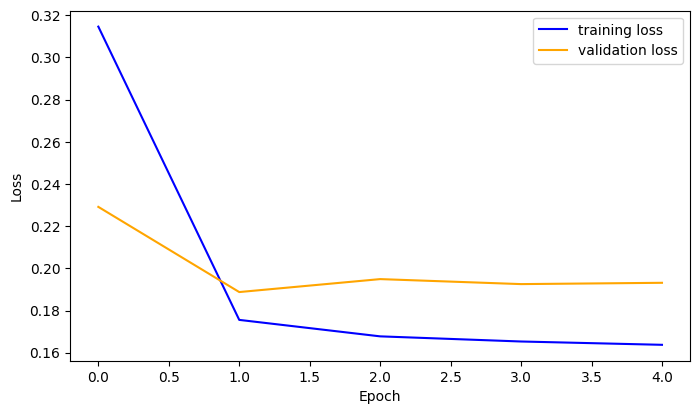

In [26]:
# Plot the training and validation loss
plt.figure(figsize = (8,10))
ax = plt.subplot(2,1,1)
plt.plot(history.history["loss"], label = "training loss", color = "blue")
plt.plot(history.history["val_loss"], label = "validation loss", color = "orange")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

Now, let's evaluate the trained model on the test set:

In [27]:
test_loss, test_rmse = model.evaluate(x_test, y_test)
print("The test loss is " + str(test_loss) + ".")
print("The test RMSE is " + str(test_rmse) + ".")

730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1923 - root_mean_squared_error: 0.4385
The test loss is 0.1932009905576706.
The test RMSE is 0.43945184350013733.


### Extracting User and Item Embedding Vectors as Latent Feature Vectors


Now that I've trained the `RecommenderNet` model, it can predict the ratings with a relatively small RMSE.

Let's print the trained model to see its layers and their parameters/weights.


In [28]:
model.summary()

Model: "recommender_net_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ user_embedding_layer            │ (None, 16)             │       542,416 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ user_bias (Embedding)           │ (None, 1)              │        33,901 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ item_embedding_layer            │ (None, 16)             │         2,016 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ item_bias (Embedding)           │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,735,379 (6.62 MB)

 Trainable params: 578,459 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,156,920 (4.41 MB)

In the `RecommenderNet`, the `user_embedding_layer` and `item_embedding_layer` layers contain the trained weights. These are the latent user and item features learned by the model that will be used to predict interactions. While training the neural network to predict ratings, the embedding layers are simultaneously trained to extract the embedding user and item features.


I can easily get the actual weights using the `model.get_layer().get_weights()` methods:


In [29]:
# User features
user_latent_features = model.get_layer('user_embedding_layer').get_weights()[0]
print(f"User features shape: {user_latent_features.shape}")

User features shape: (33901, 16)


In [30]:
user_latent_features[0]

array([-0.00881471,  0.02702582,  0.00642709, -0.00851467,  0.00305335,
        0.01081791,  0.02624575, -0.01680504, -0.00075849, -0.00949888,
        0.00159236,  0.0068766 ,  0.01731271, -0.011738  ,  0.01655133,
       -0.01085765], dtype=float32)

In [31]:
item_latent_features = model.get_layer('item_embedding_layer').get_weights()[0]
print(f"Item features shape: {item_latent_features.shape}")

Item features shape: (126, 16)


In [32]:
item_latent_features[0]

array([-0.12215935,  0.16437185,  0.27505016, -0.11286511, -0.13515748,
        0.19828828,  0.04872744, -0.01106735,  0.13019586,  0.2259188 ,
        0.01210192,  0.21332912,  0.19225287,  0.0081634 ,  0.1442508 ,
       -0.16171858], dtype=float32)

Now, each of the 33,901 users has been transformed into a 16 x 1 latent feature vector, and each of the 126 items has been transformed into a 16 x 1 latent feature vector.


### Potential Model Improvements


The `RecommenderNet` I've implemented is a basic neural network. There are several ways I could potentially improve its performance:

1. Hyperparameter tuning, such as adjusting the embedding layer dimensions
2. Adding more hidden layers to capture more complex patterns
3. Trying different activation functions such as `ReLU`
4. Experimenting with different loss functions and optimizers

These are directions I could explore in future iterations of this model.


### Summary


In this notebook, I've demonstrated how to predict course ratings using neural networks. With a trained neural network, I can extract or embed users and items into latent feature spaces and then predict the interaction between a user and an item using these latent feature vectors.

The approach provides a powerful way to capture complex patterns in user-item interactions without needing to explicitly engineer features. By learning representations directly from the data, the neural network can discover subtle patterns that might be difficult to identify manually.

In future work, I could explore model improvements, incorporate additional user and item features, or combine this approach with other recommendation techniques for a hybrid system.
